## 6. Random Forest Classifier

### 6.1 Packages importeren 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)

### 6.2 Dataset inladen 

In [ ]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# training set
X_train = train['Omschrijving']
y_train = train['Product']

# test set
X_test = test['Omschrijving']
y_test = test['Product']

### 6.3 TF-IDF en Random Forest Pipeline

In [8]:
tfidf = TfidfVectorizer(
    preprocessor=spacy_preprocessor,
    tokenizer=spacy_tokenizer,
    token_pattern=None,
    analyzer="word",
    sublinear_tf=True
)

In [9]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("rf", rf)
])

### 6.4 Hyperparameter Tuning (GridSearch)

In [ ]:
param_grid = {
    "rf__n_estimators": [200, 400], # aantal bomen 
    "rf__max_depth": [30, 60, None], # maximale diepte vd bomen 
    "rf__min_samples_leaf": [1, 2], # minimaal aantal samples per blad  
    "rf__max_features": ["sqrt"] # aantal features per split 
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="precision_macro",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBeste parameters:", grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Beste parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 400}


### 6.5 Evaluatie Modelprestaties 

#### 6.5.1 Voorspellingen

In [ ]:
y_pred_test = best_model.predict(X_test)

#### 6.5.2 Classification report

In [12]:
print("\nClassification report Random Forest Classifier:\n")
print(classification_report(y_test, y_pred_test))


Classification report Random Forest Classifier:

                    precision    recall  f1-score   support

      Bankrekening       0.90      0.78      0.84       446
Consumentenkrediet       0.83      0.31      0.45       284
        Creditcard       0.82      0.75      0.78       564
         Hypotheek       0.86      0.94      0.90       994
           Incasso       0.78      0.88      0.82      1223
Kredietregistratie       0.80      0.83      0.81       934

          accuracy                           0.82      4445
         macro avg       0.83      0.75      0.77      4445
      weighted avg       0.82      0.82      0.81      4445



#### 6.5.3 Confusion Matrix

[[ 349    1   39   21   25   11]
 [   5   87   19   58   78   37]
 [  18    2  422   14   63   45]
 [   9    0    2  938   25   20]
 [   5    6   17   40 1072   83]
 [   0    9   18   20  114  773]]


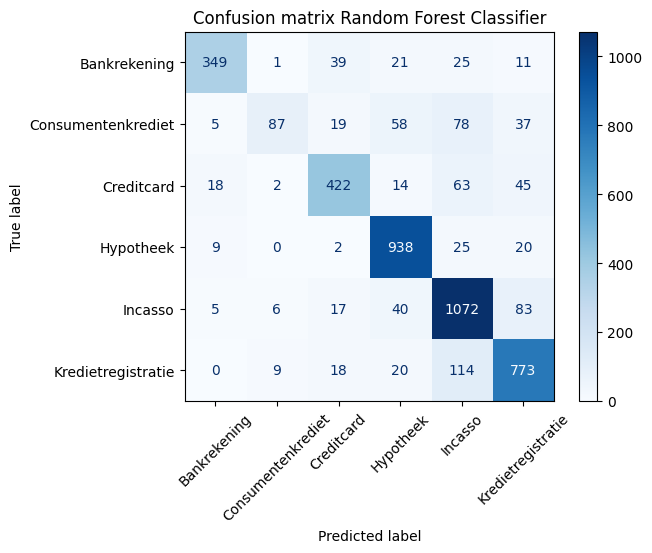

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix Random Forest Classifier')
plt.savefig("afbeeldingen/confusion_matrix_random_forest.png", dpi=300, bbox_inches='tight') 
plt.show()

### 6.5.4 Conclusie modelprestatie
De Random Forest Classifier haalt een weighted precision van 0,82 en is dus het slechtst presterende model tot nu toe. Alleen Bankrekening haalt de minimale eis van 90% precision; alle andere productsectoren blijven hier onder, met Consumentenkrediet als laagst scorende klasse.

Vergeleken met Logistic Regression, Naive Bayes en SGDClassifier presteert Random Forest het minst goed op precision. 